# Employee Performance Analysis – INX Future Inc

# Business Problem Statement

INX Future Inc. is facing a decline in overall employee performance, which has negatively impacted service delivery and client satisfaction. The management wants to understand the key drivers of employee performance without directly penalizing employees, as this may affect morale. A data-driven approach is required to identify performance patterns and provide actionable insights.

# Project Objectives

The primary objectives of this project are:

### 1) Department-wise Performance Analysis:
* Analyze employee performance across different departments
* Identify high-performing and low-performing departments

### 2) Identification of Top Factors Affecting Performance
* Determine the top 3 most influential factors impacting employee performance
* Use statistical analysis and feature importance techniques to support findings

### 3) Predictive Model Development
* Build a machine learning model that can predict employee performance based on input features
* This model can assist management during hiring and performance evaluation

### 4) Business Recommendations
* Provide data-backed recommendations to improve employee performance
* Ensure recommendations do not negatively affect employee morale

# Import required libraries 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Dataset

In [2]:
!pip install xlrd


In [3]:
df= pd.read_excel("C:/Users/asus/OneDrive/Desktop/IBAC project/INX_Future_Inc_Employee_Performance_Data.xls",engine="xlrd")
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [4]:
# Check last 5 rows
df.tail()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3
1199,E100998,24,Female,Life Sciences,Single,Sales,Sales Executive,Travel_Rarely,3,2,...,1,4,3,3,2,2,2,0,Yes,2


In [5]:
# Check overview of data
df.shape


(1200, 28)

####  Insight :
* The dataset contains 1200 records (rows) and 28 features (columns).
Rows (1200): Each row represents an individual employee.
* Columns (28): These include demographic details, job-related attributes, performance-related variables, and the target variable.

In [6]:
# check data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

#### Insights:
* The dataset contains 1200 records and 28 features with no missing values.
* It includes both numerical and categorical variables, and Performance Rating is the target variable, making it suitable for classification modeling.

In [7]:
# Check for Missing Values
df.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

#### Insights: 
* No missing values were found in the dataset
Hence, no imputation was required

In [8]:
# Check for Duplicate Records
df.duplicated().sum()

0

#### Insights: 
* No duplicate records found 

In [9]:
# Data Type Validation
df.dtypes

EmpNumber                       object
Age                              int64
Gender                          object
EducationBackground             object
MaritalStatus                   object
EmpDepartment                   object
EmpJobRole                      object
BusinessTravelFrequency         object
DistanceFromHome                 int64
EmpEducationLevel                int64
EmpEnvironmentSatisfaction       int64
EmpHourlyRate                    int64
EmpJobInvolvement                int64
EmpJobLevel                      int64
EmpJobSatisfaction               int64
NumCompaniesWorked               int64
OverTime                        object
EmpLastSalaryHikePercent         int64
EmpRelationshipSatisfaction      int64
TotalWorkExperienceInYears       int64
TrainingTimesLastYear            int64
EmpWorkLifeBalance               int64
ExperienceYearsAtThisCompany     int64
ExperienceYearsInCurrentRole     int64
YearsSinceLastPromotion          int64
YearsWithCurrManager     

#### Insights:
* The column EmpNumber was identified as a unique identifier and removed, as it does not contribute to predictive modeling.
* The dataset contains well-defined numerical and categorical features with consistent data types. Categorical variables will be encoded for modeling, while numerical variables can be directly used for analysis and machine learning.
* The target variable, PerformanceRating, is numerical, confirming the suitability of classification algorithms.

In [10]:
# Drop unnecessary columns
df.drop(columns=['EmpNumber'], inplace=True)

#### Insights: 
* EmpNumber was dropped before encoding because it is an identifier.
* Encoding it would introduce noise and bias in the model.”

In [11]:
df.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,...,4,10,2,2,10,7,0,8,No,3
1,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,...,4,20,2,3,7,7,1,7,No,3
2,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,...,3,20,2,3,18,13,1,12,No,4
3,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,...,2,23,2,2,21,6,12,6,No,3
4,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,...,4,10,1,3,2,2,2,2,No,3


# Exploratory data analysis


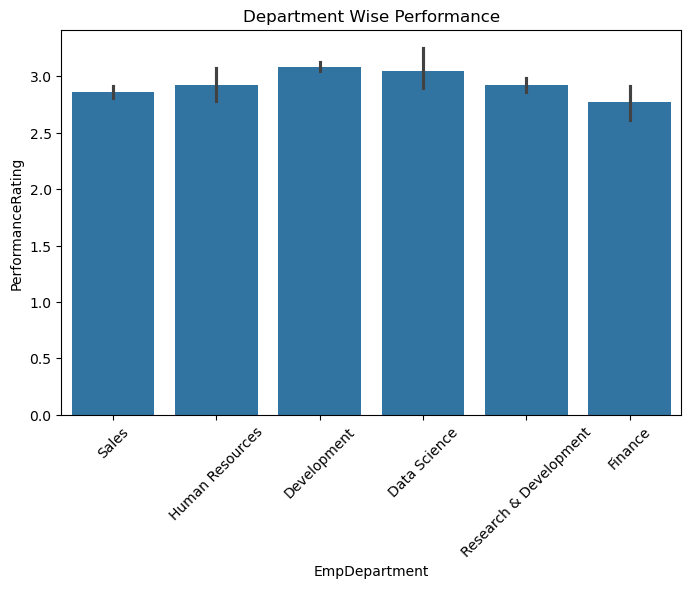

In [12]:
# Department vs Performance
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x="EmpDepartment", y="PerformanceRating", data=df)
plt.xticks(rotation=45)
plt.title("Department Wise Performance")
plt.show()

## Insights:
* Development and Data Science departments show the highest average performance ratings.Technical roles contribute more consistently to organizational performance.
* Finance department has the lowest average performance score.

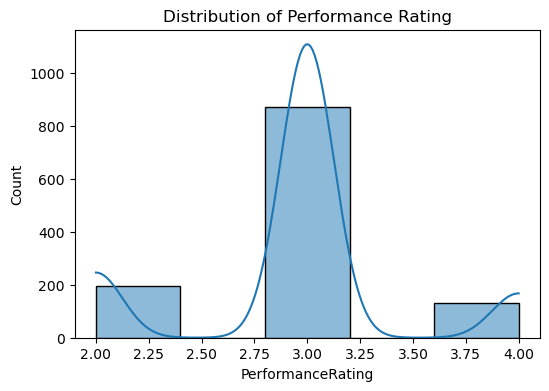

In [15]:
# Performance Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["PerformanceRating"], bins=5, kde=True)
plt.title("Distribution of Performance Rating")
plt.show()

### Insights:
* Most employees have a performance rating around 3.0.
* The distribution is approximately bell-shaped
  

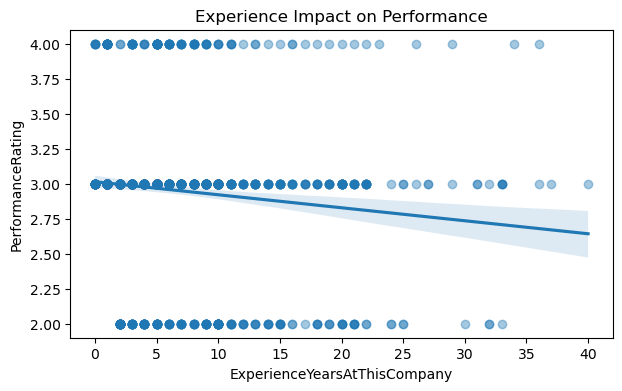

In [59]:
# Experience Impact on performance
plt.figure(figsize=(7,4))
sns.regplot(x="ExperienceYearsAtThisCompany", y="PerformanceRating", data=df, scatter_kws={"alpha":0.4})
plt.title("Experience Impact on Performance")
plt.show()



## Insights:
* The regression line shows a slight negative trend between experience and performance.This indicates that performance does not necessarily increase with longer tenure in the company.
* Employees with low to moderate experience (0–15 years) show more consistent high performance.
* Experience alone is not a strong predictor of high performance.

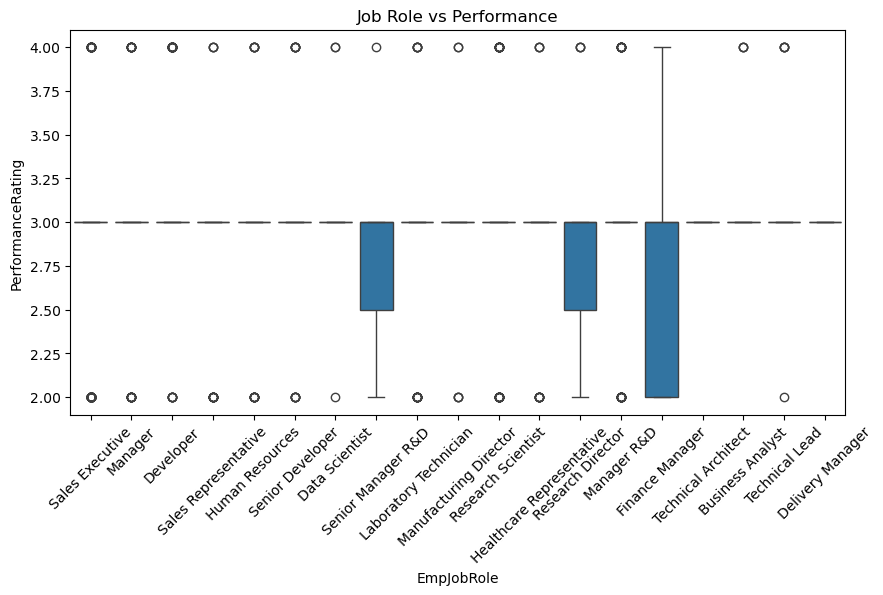

In [63]:
# Impact of Job role on performance
plt.figure(figsize=(10,5))
sns.boxplot(x="EmpJobRole", y="PerformanceRating", data=df)
plt.xticks(rotation=45)
plt.title("Job Role vs Performance")
plt.show()



## Insights:
* Technical and analytical roles (Data Scientist, Research Scientist, Developer, Technical Architect) show relatively higher and more consistent performance ratings.
* Use role-specific performance benchmarks instead of uniform evaluation standards.
* Performance differences across job roles are significant, confirming that role nature strongly influences employee output.

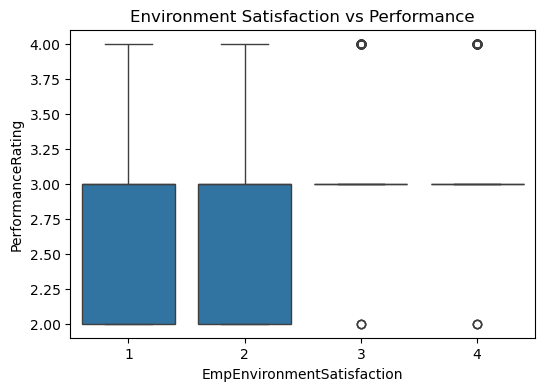

In [29]:
# Envirinment satisfaction vs performance
plt.figure(figsize=(6,4))
sns.boxplot(x="EmpEnvironmentSatisfaction", y="PerformanceRating", data=df)
plt.title("Environment Satisfaction vs Performance")
plt.show()


## Insights:
* Employees with higher environment satisfaction (Level 3–4) consistently show better performance ratings.
* Improving workplace culture and environment can significantly enhance organizational performance.

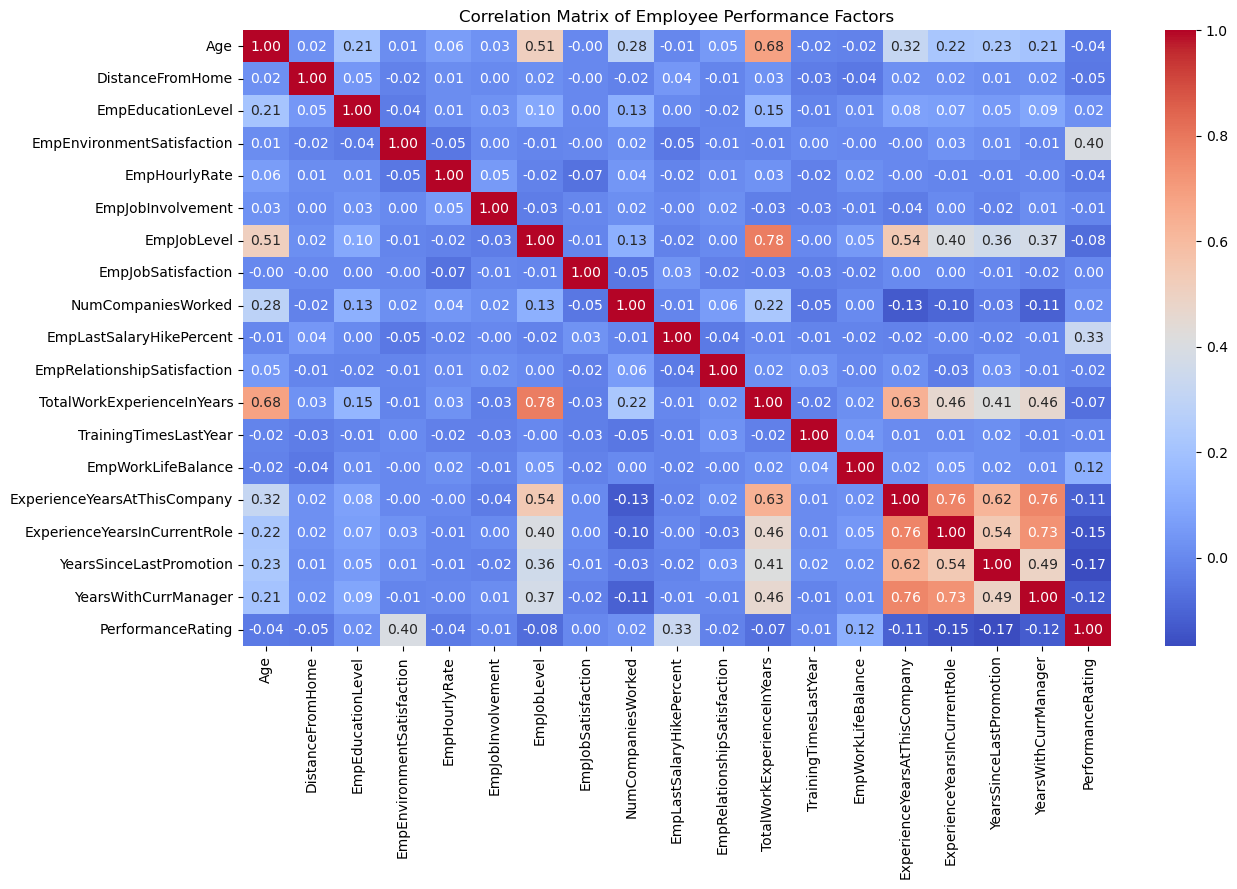

In [62]:
# correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Employee Performance Factors")
plt.show()


### Insights:
* Among all variables, environment satisfaction shows the highest positive correlation with performance, highlighting the critical role of a healthy and supportive workplace.
* Salary hike percentage also demonstrates a meaningful positive relationship, confirming that financial incentives remain an important motivator for employees.
* employee performance is strongly influenced by non-technical and motivational factors rather than by experience alone

# Summary:
1) Most employees show average performance, with only a small proportion being extreme high or low performers.

2) Development and Data Science departments outperform other functions, while Finance and Sales show comparatively lower performance.

3) Experience alone does not guarantee higher performance; continuous skill development is more impactful.

4) Technical and analytical job roles consistently demonstrate better performance than support and managerial roles.

5) Work environment satisfaction strongly influences performance.

6) Training and compensation incentives positively contribute to employee productivity

7) Overall, career growth opportunities, compensation fairness, work-life balance, and workplace environment are the key drivers of employee performance, and these should be the primary focus areas for data-driven HR and management strategies.

   